# Spectral Analysis
This exercise builds a tool for the spectral analysis of the magnetic field data resting from your simulations in Exercise 6.1. The goal of this assignment is to design a Fourier-space diagnostic, apply it to PIC field data, and interpret the results in terms of numerical dispersion and aliasing.

In [1]:
# Import necessary libraries
import nt2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm
from scipy.signal import windows

In [2]:
# Load the simulation data from disk
# 'Data' is the main container for the simulation dataset (replace with your location)
data = nt2.Data("/dartfs/rc/lab/E/EPaCO/phys118/godfrey/hw6/run1/cherenkov_boris_vxy")

In [3]:
# Select field data 
fdata = data.fields

In [4]:
# Generate a 3D array Bz(t, x, y) for FFT in space and time
Bz_list = []

for i in tqdm(range(400,451)):
    bz_array = np.array(fdata.isel(t=i).Bz.load()).T
    Bz_list.append(bz_array)

Bz = np.stack(Bz_list, axis=0)

100%|██████████| 51/51 [00:05<00:00,  9.34it/s]


In [5]:
# Provide dimensions and parameters for FFT
Nt, Nx, Ny = Bz.shape

x_array = np.array(fdata.isel(t=0).x.load())
y_array = np.array(fdata.isel(t=0).x.load()) ######should be y?

dx = x_array[1] - x_array[0]
dy = y_array[1] - y_array[0]
dt = 0.1

## A) 
- You are provided with a NumPy array $Bz$ with shape ($N_t , N_x , N_y$), and several parameters like grid spacing ($\Delta x , \Delta y$) and time-stepping $\Delta t$. 
- Build the Fourier axes of this configuration as arrays with the discrete spectral points ($\omega , k_x , k_y$).
- You can use the functions "np.fft.fftshift" and "np.ftt.fftfreq".
- Verify that the dimensions of your Fourier arrays are consistent with the shape of $Bz$.

In [6]:
omega = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(Nt, d=dt))  # rad / time
kx    = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))  # rad / length
ky    = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(Ny, d=dy))  # rad / length

Bz_hat = np.fft.fftn(Bz, axes=(0, 1, 2))
Bz_hat = np.fft.fftshift(Bz_hat, axes=(0, 1, 2))

print("Bz (Nt, Nx, Ny)        = ", Bz.shape)
print("Bz_hat (omega, kx, ky) = ", Bz_hat.shape)

Bz (Nt, Nx, Ny)        =  (51, 1024, 1024)
Bz_hat (omega, kx, ky) =  (51, 1024, 1024)


## B) 
- Conduct a 2D Fourier analysis of the field $B_z (x,y)$ at one snapshot in time that shows substantial instability growth.
- You can use the function "np.fft.ftt2".
- Show a 2D heat map ("plt.pcolormesh") of the power in the Fourier modes $|\hat{B_z} (k_x , k_y)|$.
- Describe the qualitative structure of the spectrum.
- Hint: The dominant structures in the 2D spectrum do not necessarily align with the beam direction.

In [7]:
# growth proxy: mean-squared field vs time
E_t = np.mean(Bz**2, axis=(1,2))

# pick a time late in the growth but not necessarily the very last frame
# (argmax is also okay; this version picks ~80% of the way to the max)
# If you already know the time index from a plot/animation, just set t_idx = ...
t_idx = 40

print("chosen t_idx:", t_idx, "E_t:", E_t[t_idx])

chosen t_idx: 40 E_t: 1.0391177


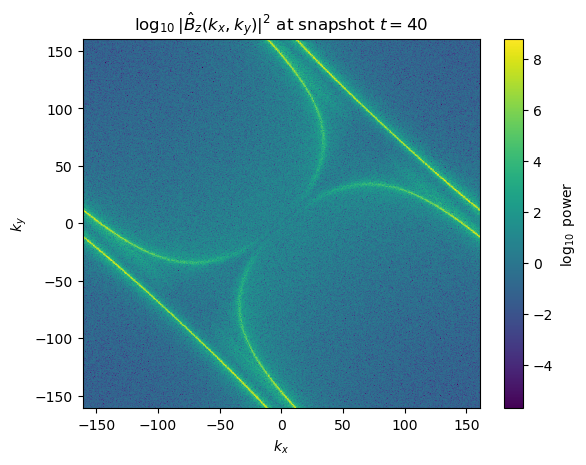

In [8]:
Bxy = Bz[t_idx, :, :] # snapshot in time
Bxy = Bxy - np.mean(Bxy) # remove DC component - chat recommended

win_x = windows.hann(Nx)[:, None]
win_y = windows.hann(Ny)[None, :]
Bxy_win = Bxy * win_x * win_y

Bhat_k = np.fft.fftshift(np.fft.fft2(Bxy_win))
power_k = np.abs(Bhat_k)**2  #  |B̂z(kx,ky)|^2

KX, KY = np.meshgrid(kx, ky, indexing="ij")

plt.figure()
plt.pcolormesh(KX, KY, np.log10(power_k + 1e-30), shading="auto") # added 1e-30 so log10 never sees zeros - chat recommended
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(r"$\log_{10} |\hat{B}_z(k_x,k_y)|^2$ at snapshot $t=40$")
plt.colorbar(label=r"$\log_{10}$ power")
plt.savefig("log_power_40.png", dpi=300)

Qualitative structure of of the spectrum
- Symmetry: Because Bz(x,y) is real-valued, the spectrum typically shows conjugate symmetry, so power appears in symmetric locations in (kx,ky) (e.g., features mirrored across the origin).
- Dominant lobes / spots (unstable modes): Instability-driven growth often shows up as localized peaks or lobes at particular (kx,ky), not just a blob at the origin.
- Oblique structure (hint-relevant): The strongest peaks/ridges may lie along oblique angles in (kx,ky), meaning the dominant modes have both kx and ky components. This is exactly what the hint is warning about: the most unstable numerical/beam-driven modes can be oblique, so they don’t have to align with the beam direction.
- Broadening / nonlinear stage: If the snapshot is later (near saturation), peaks can broaden into a thicker band or more isotropic “cloud” as modes couple nonlinearly.
- High-k noise / grid effects: You may see extra power accumulating near the Nyquist edges (kx∼π/dx, ky∼π/dy) from particle noise, filtering artifacts, or aliasing.


## C) 
- To actually confirm that we are seeing modes of Cherenkov radiation, we have to expand our analysis into the time-domain.
- Apply a suitable temporal window to the field data to reduce spectral leakage using a function like "windows.hann" in "scipy.signal".
- Compute the three-dimensional Fourier transform of the windowed field over the coordinates using "np.fft.fftn".
- Calculate the Fourier power $|\hat{B_z} (\omega , k_x , k_y)|$.

In [9]:
win_t = windows.hann(Nt)[:, None, None]      # shape (Nt,1,1) -> broadcasts over x,y
Bz_win = Bz * win_t

# 3D FFT over (t, x, y)
Bz_hat = np.fft.fftn(Bz_win, axes=(0, 1, 2))          # shape (Nt, Nx, Ny)
Bz_hat = np.fft.fftshift(Bz_hat, axes=(0, 1, 2))      # center (omega, kx, ky)

# Fourier Power
power_kw = np.abs(Bz_hat)**2       # |B̂z(ω,kx,ky)|^2
print(power_kw.shape)
print(power_kw)

(51, 1024, 1024)
[[[1.03743060e+02 1.82342289e+01 1.14790574e+01 ... 2.07457765e+01
   1.54593069e+01 1.09065164e+01]
  [9.21943104e+00 7.13494482e+01 6.74331852e+01 ... 5.69363142e+01
   9.00840192e+01 2.17816523e+01]
  [2.06339665e+01 2.05994718e+02 1.85554199e+02 ... 9.29844726e+01
   6.54426064e+01 9.74674090e+01]
  ...
  [1.20079475e+01 6.58842476e+00 5.39569523e+00 ... 3.06159139e+01
   9.48229265e+01 1.56460364e+01]
  [1.12718381e+01 8.35306545e+01 7.16901836e+01 ... 1.64425483e+00
   1.13993903e+02 2.06888304e+02]
  [1.30954457e+01 2.49812715e+01 7.39024300e+01 ... 3.30770429e+01
   5.27368976e+01 7.22611297e+01]]

 [[8.55602785e+00 4.13711689e+00 1.18156057e-01 ... 2.61953933e-01
   2.30854139e+00 9.14623203e-01]
  [8.75642520e-01 1.94339809e+00 5.94712970e+00 ... 5.96483647e+00
   7.94171963e+00 2.11619553e+00]
  [3.25042739e+00 1.55148498e+01 2.71673898e+01 ... 9.27514161e+00
   2.17543873e+00 1.04230653e+01]
  ...
  [1.45219140e+00 3.36440082e-01 1.08636369e-01 ... 5.257067

## D) 
- In your simulation, the relativistic beam was initialized with momentum $u_{beam}$.
- Construct the corresponding unit vector $\hat{e_{\parallel}}$ pointing along the beam direction. Using the Fourier wave-number grid arrays $k_x$ and $k_y$, compute the beam-parallel wave number $k_{\parallel}=k_x e_{\parallel}^x + k_y e_{\parallel}^y$

In [11]:
# defining u_beam
drifts_in_x = [70.71, 70.71, 70.71, 70.71]
drifts_in_y = [70.71, 70.71, 70.71, 70.71]
v = 0
u_xy = np.array([drifts_in_x[v], drifts_in_y[v]], dtype=float)

# unit vector along beam direction
e_par = u_xy / np.linalg.norm(u_xy)  # chatGPT suggested using
epar_x, epar_y = e_par
print("e_parallel =", e_par)

# 2D wavenumber grids (same as part B)
KX, KY = np.meshgrid(kx, ky, indexing="ij")

# beam-parallel wavenumber
k_par = KX * epar_x + KY * epar_y
print("k_par shape:", k_par.shape)
print(k_par)

e_parallel = [0.70710678 0.70710678]
k_par shape: (1024, 1024)
[[-2.27475606e+02 -2.27253462e+02 -2.27031318e+02 ... -6.66432441e-01
  -4.44288294e-01 -2.22144147e-01]
 [-2.27253462e+02 -2.27031318e+02 -2.26809174e+02 ... -4.44288294e-01
  -2.22144147e-01  0.00000000e+00]
 [-2.27031318e+02 -2.26809174e+02 -2.26587030e+02 ... -2.22144147e-01
   0.00000000e+00  2.22144147e-01]
 ...
 [-6.66432441e-01 -4.44288294e-01 -2.22144147e-01 ...  2.26142742e+02
   2.26364886e+02  2.26587030e+02]
 [-4.44288294e-01 -2.22144147e-01  0.00000000e+00 ...  2.26364886e+02
   2.26587030e+02  2.26809174e+02]
 [-2.22144147e-01  0.00000000e+00  2.22144147e-01 ...  2.26587030e+02
   2.26809174e+02  2.27031318e+02]]


## E) 
- Construct a reduced spectrum $|\hat{B_z}(\omega , k_{\parallel})|$ by binning the power $|\hat{B_z}(\omega , k_x , k_y)|$ according to their value of $k_{\parallel}$ (i.e. summing power within finite $k_{\parallel}$ intervals).
- Overlay lines of the for $\omega=v_{beam} k_{\parallel} + b$, where $v_{beam}$ is the three-velocity of the initial beam and $b$ is a suitably chosen constant.
- Do your dominant spectral features follow the approximately linear relation?
- Are multiple parallel branches visible?
- If so, you have to identified the numerical growth of Cherenkov radiation!
- Hint: You should not expect exact agreement for all branches; qualitative alignment of dominant features with the slope is sufficient.

In [14]:
# k_parallel bins
Nkpar = 400  # adjust as desired (200–800 is typical)
kpar_min, kpar_max = k_par.min(), k_par.max()
edges = np.linspace(kpar_min, kpar_max, Nkpar + 1)
kpar_centers = 0.5 * (edges[:-1] + edges[1:])

# Precompute bin index for each (kx,ky) point
kpar_flat = k_par.ravel()
bin_idx = np.digitize(kpar_flat, edges) - 1    # 0 ... Nkpar-1
valid = (bin_idx >= 0) & (bin_idx < Nkpar)
bin_idx = bin_idx[valid]

# Flatten spatial dims
power_flat = power_kw.reshape(power_kw.shape[0], -1)[:, valid]

# Reduced spectrum: bin power according to k_parallel bins
reduced_power = np.zeros((power_kw.shape[0], Nkpar), dtype=float)

# loop over omega index
for it in range(power_kw.shape[0]):  
    reduced_power[it, :] = np.bincount(
        bin_idx,
        weights=power_flat[it, :],
        minlength=Nkpar
    )

# Beam speed from u (assuming u = gamma*v/c)
u_mag = np.linalg.norm(u_xy)
gamma = np.sqrt(1.0 + u_mag**2)
beta  = u_mag / gamma          # v/c
v_beam = beta    

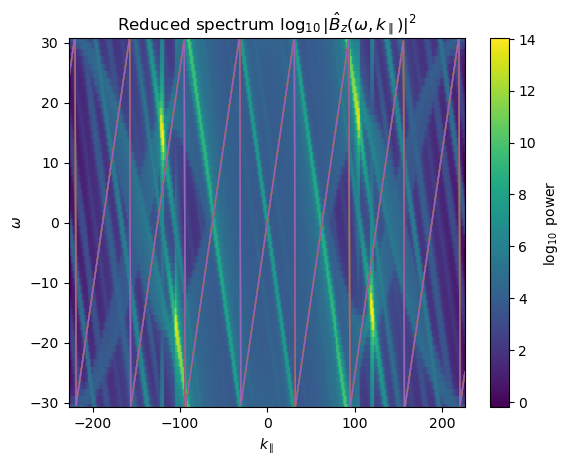

In [16]:
# Plot reduced spectrum
plt.figure()
plt.pcolormesh(
    kpar_centers, omega,
    np.log10(reduced_power + 1e-30),
    shading="auto"
)
plt.xlabel(r"$k_{\parallel}$")
plt.ylabel(r"$\omega$")
plt.title(r"Reduced spectrum $\log_{10}|\hat{B}_z(\omega,k_\parallel)|^2$")
plt.colorbar(label=r"$\log_{10}$ power")

# Overlay Cherenkov lines
omega_max = np.pi / dt
Omega_period = 2*np.pi / dt

def wrap_omega(w):
    return ((w + omega_max) % (2*omega_max)) - omega_max

n_list = [-2, -1, 0, 1, 2]   # branches
for n in n_list:
    b = n * Omega_period
    omega_line = wrap_omega(v_beam * kpar_centers + b)
    plt.plot(kpar_centers, omega_line, linewidth=1)

plt.ylim(omega.min(), omega.max())
plt.show()
#plt.savefig("reduced-spectrum.png", dpi=300)